<a href="https://colab.research.google.com/github/abhi6988/Group-7/blob/main/DL_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
dataset_path = "/content/drive/MyDrive/Colab Notebooks/dataset-resized"

print(dataset_path)

/content/drive/MyDrive/Colab Notebooks/dataset-resized


In [6]:
import os

classes = sorted(os.listdir(dataset_path))

print("Classes:")
for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        print(f"{class_name}: {len(os.listdir(class_path))} images")

Classes:
cardboard: 403 images
glass: 501 images
metal: 410 images
paper: 594 images
plastic: 482 images
trash: 137 images


In [7]:
total_images = 0

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        total_images += len(os.listdir(class_path))

print("Total images:", total_images)

Total images: 2527


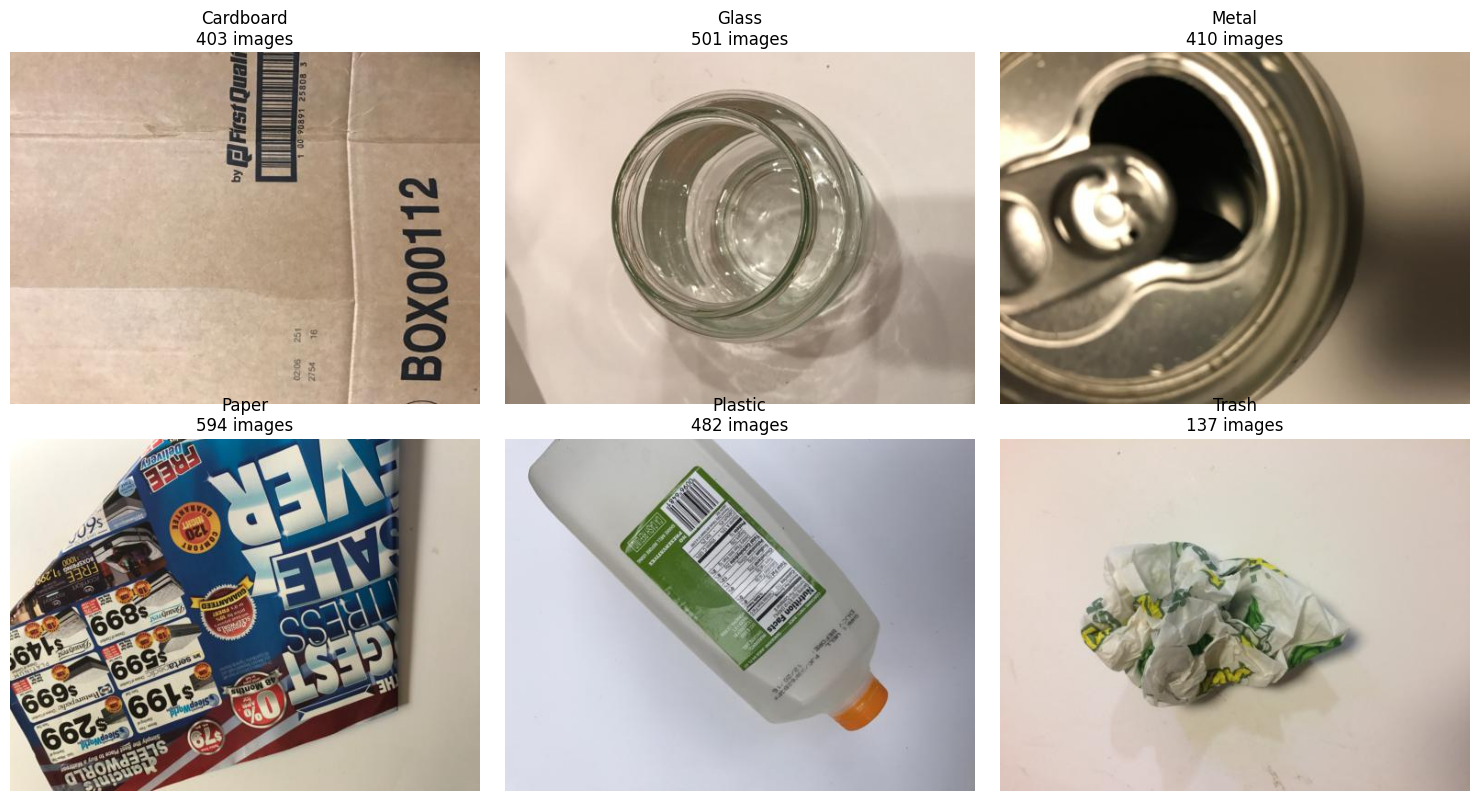

In [8]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Dataset path
dataset_path = "/content/drive/MyDrive/Colab Notebooks/dataset-resized"

# Get class names
classes = sorted([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

# Display one sample image from each class
plt.figure(figsize=(15, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)

    # Get image files
    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    # Select first image
    image_path = os.path.join(class_path, image_files[0])
    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(f"{class_name.capitalize()}\n{len(image_files)} images")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
from PIL import Image
import os

dataset_path = "/content/drive/MyDrive/Colab Notebooks/dataset-resized"

# Check dimensions of a few images from each class
for class_name in sorted(os.listdir(dataset_path)):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        image_path = os.path.join(class_path, image_files[0])
        image = Image.open(image_path)

        print(f"{class_name}: {image.size}, mode = {image.mode}")

cardboard: (512, 384), mode = RGB
glass: (512, 384), mode = RGB
metal: (512, 384), mode = RGB
paper: (512, 384), mode = RGB
plastic: (512, 384), mode = RGB
trash: (512, 384), mode = RGB


In [10]:
import tensorflow as tf

dataset_path = "/content/drive/MyDrive/Colab Notebooks/dataset-resized"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

# Training dataset - 70%
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels="inferred",
    label_mode="int",
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Temporary validation + test dataset - 30%
temp_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels="inferred",
    label_mode="int",
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Split the 30% into 15% validation + 15% test
temp_batches = tf.data.experimental.cardinality(temp_ds).numpy()

val_batches = temp_batches // 2

val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

print("Classes:", train_ds.class_names)
print("Number of training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Number of validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Number of test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Found 2527 files belonging to 6 classes.
Using 1769 files for training.
Found 2527 files belonging to 6 classes.
Using 758 files for validation.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Number of training batches: 56
Number of validation batches: 12
Number of test batches: 12


In [11]:
import tensorflow as tf

dataset_path = "/content/drive/MyDrive/Colab Notebooks/dataset-resized"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

# -----------------------------
# 70% Training
# -----------------------------
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels="inferred",
    label_mode="int",
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# -----------------------------
# 30% Temporary dataset
# -----------------------------
temp_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels="inferred",
    label_mode="int",
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=None,
    shuffle=True
)

# Shuffle the 758 images
temp_ds = temp_ds.shuffle(
    buffer_size=758,
    seed=SEED,
    reshuffle_each_iteration=False
)

# Number of images for validation
total_temp = 758
val_size = total_temp // 2

# 15% validation
val_ds = temp_ds.take(val_size)

# 15% test
test_ds = temp_ds.skip(val_size)

# Batch them
val_ds = val_ds.batch(BATCH_SIZE)
test_ds = test_ds.batch(BATCH_SIZE)

print("Classes:", train_ds.class_names)

print(
    "Training images:",
    1769
)

print(
    "Validation images:",
    val_size
)

print(
    "Test images:",
    total_temp - val_size
)

Found 2527 files belonging to 6 classes.
Using 1769 files for training.
Found 2527 files belonging to 6 classes.
Using 758 files for validation.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Training images: 1769
Validation images: 379
Test images: 379


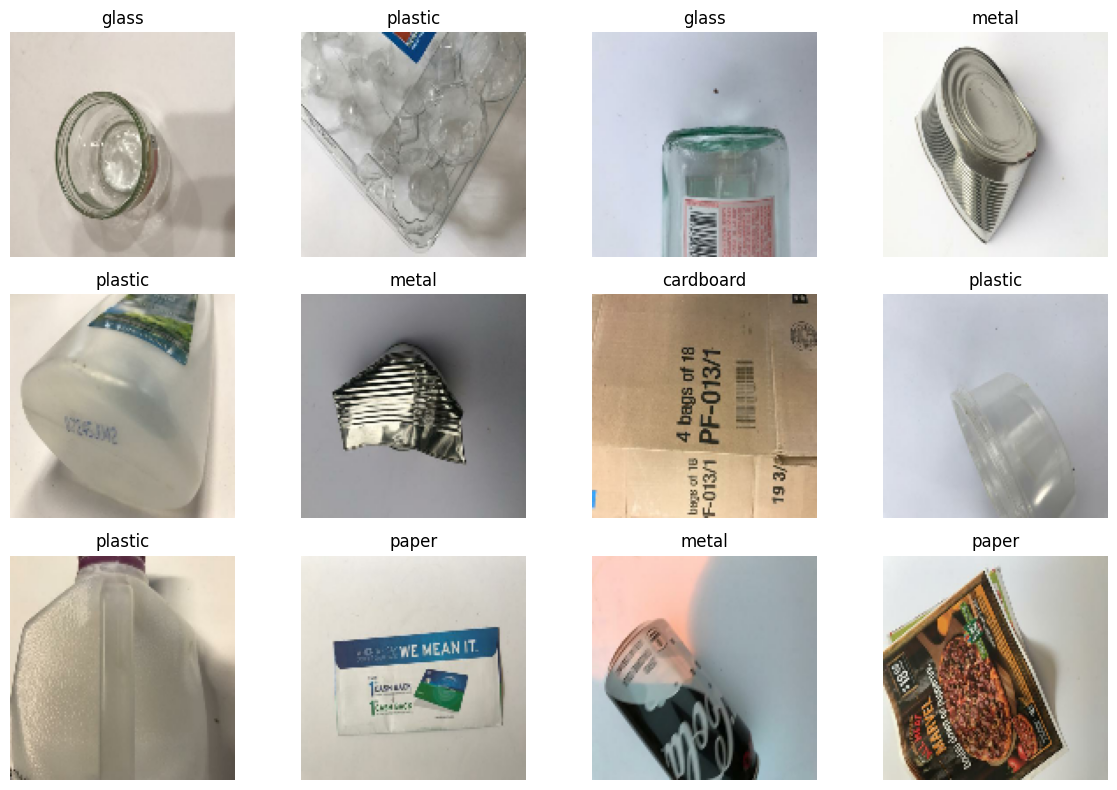

In [12]:
import matplotlib.pyplot as plt

# Get one batch from training data
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(train_ds.class_names[labels[i].numpy()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel value range:", images.numpy().min(), "to", images.numpy().max())

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Pixel value range: 0.0 to 255.0


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Number of classes
num_classes = 6

# Build MLP model
mlp_model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    # Normalize pixel values from 0-255 to 0-1
    layers.Rescaling(1./255),

    # Convert image into a 1D vector
    layers.Flatten(),

    # Hidden layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.30),

    layers.Dense(64, activation='relu'),

    # Output layer
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
mlp_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display architecture
mlp_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,300,230 (24.03 MB)

 Trainable params: 6,300,230 (24.03 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_mlp = mlp_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 275s 5s/step - accuracy: 0.1849 - loss: 1.9952 - val_accuracy: 0.2137 - val_loss: 1.7811
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.1962 - loss: 1.7742 - val_accuracy: 0.1821 - val_loss: 1.7702
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.1962 - loss: 1.7634 - val_accuracy: 0.1926 - val_loss: 1.7624
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.1962 - loss: 1.7549 - val_accuracy: 0.2216 - val_loss: 1.7497
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.1962 - loss: 1.7480 - val_accuracy: 0.2032 - val_loss: 1.7425
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.2148 - loss: 1.7425 - val_accuracy: 0.2296 - val_loss: 1.7391
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.2369 - loss: 1.7378 - val_accuracy: 0.2559 - val_loss: 1.7277
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.2369 - loss: 1.7341 - val_accuracy: 0.2322 - v

In [17]:
# Evaluate MLP on the test dataset

test_loss_mlp, test_accuracy_mlp = mlp_model.evaluate(test_ds)

print("MLP Test Loss:", test_loss_mlp)
print("MLP Test Accuracy:", test_accuracy_mlp)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2296 - loss: 1.7288
MLP Test Loss: 1.7287782430648804
MLP Test Accuracy: 0.22955144941806793


In [18]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# True labels
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = mlp_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=train_ds.class_names,
    digits=4
))

              precision    recall  f1-score   support

   cardboard     0.0000    0.0000    0.0000        51
       glass     0.0000    0.0000    0.0000        80
       metal     0.0000    0.0000    0.0000        65
       paper     0.2243    1.0000    0.3664        85
     plastic     0.0000    0.0000    0.0000        72
       trash     0.0000    0.0000    0.0000        26

    accuracy                         0.2243       379
   macro avg     0.0374    0.1667    0.0611       379
weighted avg     0.0503    0.2243    0.0822       379



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


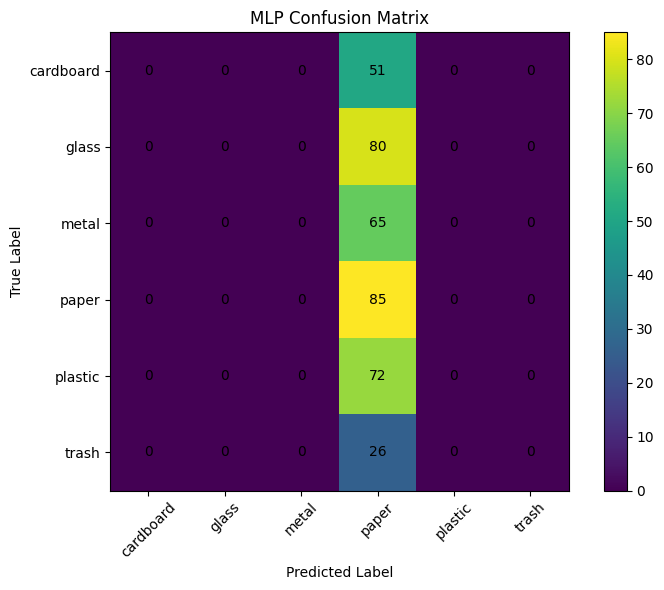

In [19]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(
    range(len(train_ds.class_names)),
    train_ds.class_names,
    rotation=45
)

plt.yticks(
    range(len(train_ds.class_names)),
    train_ds.class_names
)

# Add numbers to cells
for i in range(len(train_ds.class_names)):
    for j in range(len(train_ds.class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models

cnn_model = models.Sequential([

    # Input + normalization
    layers.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Classification section
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.30),

    # Six waste classes
    layers.Dense(6, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 16s 173ms/step - accuracy: 0.2985 - loss: 1.6607 - val_accuracy: 0.4301 - val_loss: 1.4210
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.4703 - loss: 1.3276 - val_accuracy: 0.4908 - val_loss: 1.3252
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.5455 - loss: 1.2080 - val_accuracy: 0.5515 - val_loss: 1.2329
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.6020 - loss: 1.0669 - val_accuracy: 0.5013 - val_loss: 1.2119
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.6173 - loss: 1.0083 - val_accuracy: 0.5726 - val_loss: 1.1635
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.6665 - loss: 0.9010 - val_accuracy: 0.5515 - val_loss: 1.1873
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.7168 - loss: 0.7968 - val_accuracy: 0.5963 - val_loss: 1.1598
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.7253 - loss: 0.7204 - val_accuracy: 0.6095 -

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Build a fresh CNN
final_cnn = models.Sequential([

    layers.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Classification
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.30),

    # Output
    layers.Dense(6, activation='softmax')
])

final_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_final_cnn = final_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - accuracy: 0.3290 - loss: 1.5747 - val_accuracy: 0.3852 - val_loss: 1.5205
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.4799 - loss: 1.3374 - val_accuracy: 0.4802 - val_loss: 1.2735
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.5195 - loss: 1.2340 - val_accuracy: 0.4617 - val_loss: 1.2508
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - accuracy: 0.5783 - loss: 1.1216 - val_accuracy: 0.5435 - val_loss: 1.2692
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.6105 - loss: 1.0308 - val_accuracy: 0.5752 - val_loss: 1.0871
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.6569 - loss: 0.9043 - val_accuracy: 0.5620 - val_loss: 1.1702
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.7089 - loss: 0.8078 - val_accuracy: 0.5646 - val_loss: 1.2334
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.7422 - loss: 0.7179 - val_accuracy: 0.6095 

In [24]:
test_loss_cnn, test_accuracy_cnn = final_cnn.evaluate(test_ds)

print("CNN Test Loss:", test_loss_cnn)
print("CNN Test Accuracy:", test_accuracy_cnn)

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6016 - loss: 1.0822
CNN Test Loss: 1.0821633338928223
CNN Test Accuracy: 0.6015831232070923


In [25]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true_cnn = []
y_pred_cnn = []

for images, labels in test_ds:
    predictions = final_cnn.predict(images, verbose=0)

    y_true_cnn.extend(labels.numpy())
    y_pred_cnn.extend(np.argmax(predictions, axis=1))

y_true_cnn = np.array(y_true_cnn)
y_pred_cnn = np.array(y_pred_cnn)

print(classification_report(
    y_true_cnn,
    y_pred_cnn,
    target_names=train_ds.class_names,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

   cardboard     0.6389    0.8070    0.7132        57
       glass     0.4173    0.7361    0.5327        72
       metal     0.5161    0.2667    0.3516        60
       paper     0.7848    0.7045    0.7425        88
     plastic     0.6462    0.5060    0.5676        83
       trash     0.8000    0.2105    0.3333        19

    accuracy                         0.5884       379
   macro avg     0.6339    0.5385    0.5402       379
weighted avg     0.6209    0.5884    0.5775       379



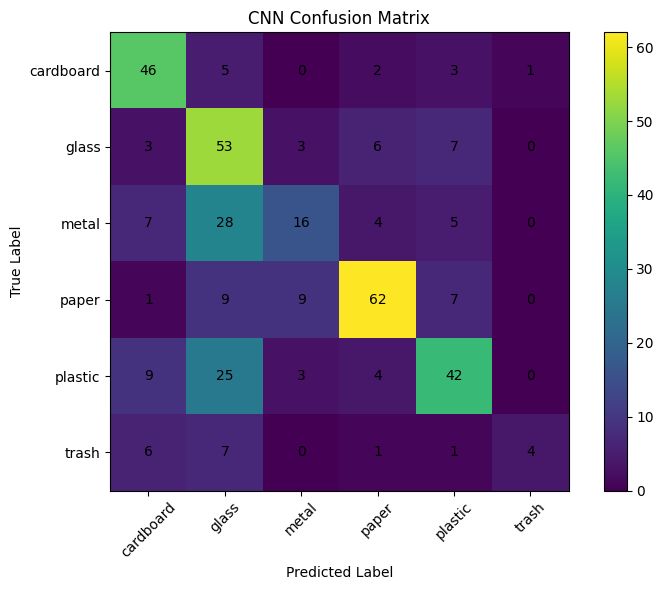

In [26]:
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

plt.figure(figsize=(8, 6))
plt.imshow(cm_cnn)
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(
    range(len(train_ds.class_names)),
    train_ds.class_names,
    rotation=45
)

plt.yticks(
    range(len(train_ds.class_names)),
    train_ds.class_names
)

for i in range(len(train_ds.class_names)):
    for j in range(len(train_ds.class_names)):
        plt.text(
            j, i, cm_cnn[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [27]:
print("Number of test samples:", len(y_true_cnn))
print("Correct predictions:", np.sum(y_true_cnn == y_pred_cnn))
print("Manual accuracy:", np.mean(y_true_cnn == y_pred_cnn))

Number of test samples: 379
Correct predictions: 223
Manual accuracy: 0.5883905013192612


In [28]:
print("Number of test samples:", len(y_true_cnn))
print("Correct predictions:", np.sum(y_true_cnn == y_pred_cnn))
print("Manual accuracy:", np.mean(y_true_cnn == y_pred_cnn))

Number of test samples: 379
Correct predictions: 223
Manual accuracy: 0.5883905013192612


In [29]:
import numpy as np
from sklearn.metrics import roc_auc_score

# Class names
class_names = train_ds.class_names
num_classes = len(class_names)

# ---------------------------------
# MLP probabilities
# ---------------------------------
y_true_mlp = []
y_prob_mlp = []

for images, labels in test_ds:
    probabilities = mlp_model.predict(images, verbose=0)

    y_true_mlp.extend(labels.numpy())
    y_prob_mlp.extend(probabilities)

y_true_mlp = np.array(y_true_mlp)
y_prob_mlp = np.array(y_prob_mlp)

# ---------------------------------
# CNN probabilities
# ---------------------------------
y_true_cnn = []
y_prob_cnn = []

for images, labels in test_ds:
    probabilities = final_cnn.predict(images, verbose=0)

    y_true_cnn.extend(labels.numpy())
    y_prob_cnn.extend(probabilities)

y_true_cnn = np.array(y_true_cnn)
y_prob_cnn = np.array(y_prob_cnn)

print("MLP probability shape:", y_prob_mlp.shape)
print("CNN probability shape:", y_prob_cnn.shape)

MLP probability shape: (379, 6)
CNN probability shape: (379, 6)


In [30]:
from sklearn.preprocessing import label_binarize

# Convert true labels to one-hot format
y_true_mlp_binary = label_binarize(
    y_true_mlp,
    classes=np.arange(num_classes)
)

y_true_cnn_binary = label_binarize(
    y_true_cnn,
    classes=np.arange(num_classes)
)

# Multiclass ROC-AUC using One-vs-Rest
auc_mlp = roc_auc_score(
    y_true_mlp_binary,
    y_prob_mlp,
    multi_class="ovr",
    average="macro"
)

auc_cnn = roc_auc_score(
    y_true_cnn_binary,
    y_prob_cnn,
    multi_class="ovr",
    average="macro"
)

print("MLP Macro AUC:", round(auc_mlp, 4))
print("CNN Macro AUC:", round(auc_cnn, 4))

MLP Macro AUC: 0.4988
CNN Macro AUC: 0.8767


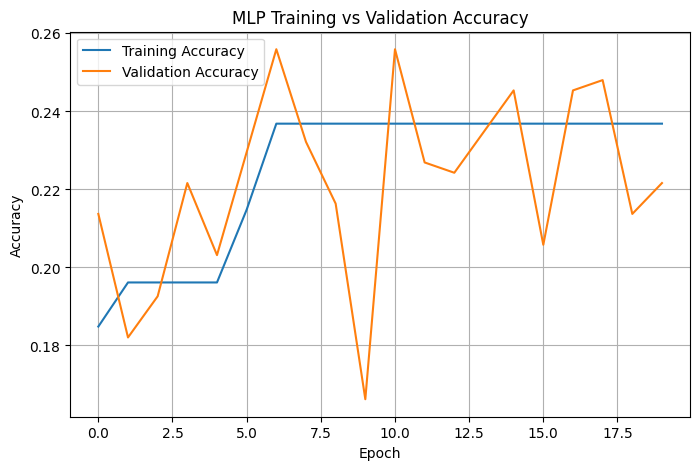

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history_mlp.history['accuracy'], label='Training Accuracy')
plt.plot(history_mlp.history['val_accuracy'], label='Validation Accuracy')

plt.title('MLP Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

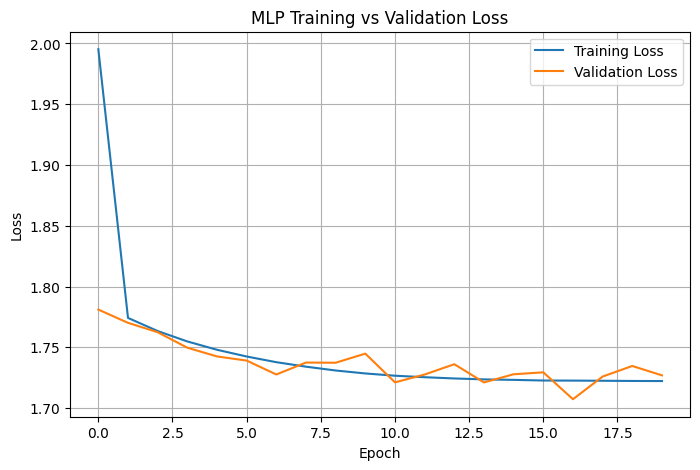

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(history_mlp.history['loss'], label='Training Loss')
plt.plot(history_mlp.history['val_loss'], label='Validation Loss')

plt.title('MLP Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

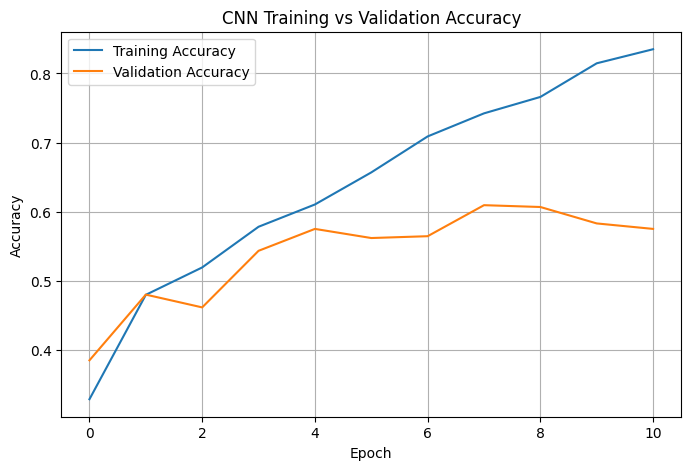

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_final_cnn.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_final_cnn.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('CNN Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

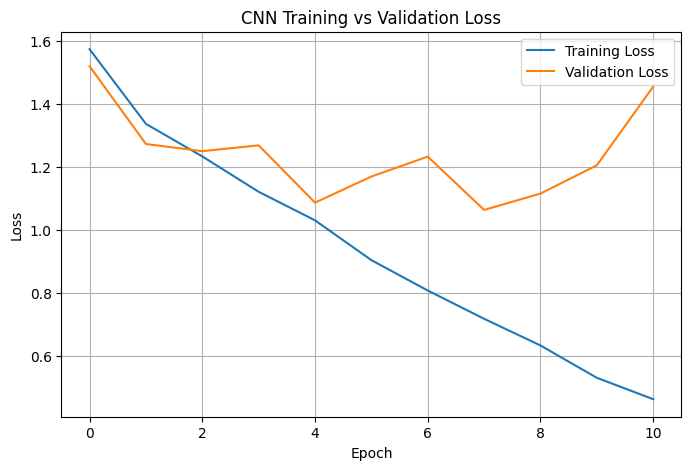

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_final_cnn.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_final_cnn.history['val_loss'],
    label='Validation Loss'
)

plt.title('CNN Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
import pandas as pd

# MLP metrics
mlp_accuracy = accuracy_score(y_true_mlp, np.argmax(y_prob_mlp, axis=1))
mlp_precision = precision_score(
    y_true_mlp, np.argmax(y_prob_mlp, axis=1),
    average='macro', zero_division=0
)
mlp_recall = recall_score(
    y_true_mlp, np.argmax(y_prob_mlp, axis=1),
    average='macro', zero_division=0
)
mlp_f1 = f1_score(
    y_true_mlp, np.argmax(y_prob_mlp, axis=1),
    average='macro', zero_division=0
)

# CNN metrics
cnn_accuracy = accuracy_score(y_true_cnn, np.argmax(y_prob_cnn, axis=1))
cnn_precision = precision_score(
    y_true_cnn, np.argmax(y_prob_cnn, axis=1),
    average='macro', zero_division=0
)
cnn_recall = recall_score(
    y_true_cnn, np.argmax(y_prob_cnn, axis=1),
    average='macro', zero_division=0
)
cnn_f1 = f1_score(
    y_true_cnn, np.argmax(y_prob_cnn, axis=1),
    average='macro', zero_division=0
)

comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Macro Precision',
        'Macro Recall',
        'Macro F1',
        'Macro AUC'
    ],
    'MLP': [
        mlp_accuracy,
        mlp_precision,
        mlp_recall,
        mlp_f1,
        auc_mlp
    ],
    'CNN': [
        cnn_accuracy,
        cnn_precision,
        cnn_recall,
        cnn_f1,
        auc_cnn
    ]
})

comparison

,Metric,MLP,CNN
0,Accuracy,0.229551,0.606860
1,Macro Precision,0.038259,0.631539
2,Macro Recall,0.166667,0.550226
3,Macro F1,0.062232,0.540758
4,Macro AUC,0.498799,0.876750


In [36]:
import tensorflow as tf
import numpy as np

dataset_path = "/content/drive/MyDrive/Colab Notebooks/dataset-resized"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

# IMPORTANT: shuffle=False
# This creates a fixed, deterministic ordering.
full_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=None,
    shuffle=False
)

# Total = 2527
all_images = []
all_labels = []

for image, label in full_ds:
    all_images.append(image.numpy())
    all_labels.append(label.numpy())

all_images = np.array(all_images)
all_labels = np.array(all_labels)

print("Total images:", len(all_images))
print("Image shape:", all_images.shape)
print("Label shape:", all_labels.shape)

Found 2527 files belonging to 6 classes.
Total images: 2527
Image shape: (2527, 128, 128, 3)
Label shape: (2527,)


In [37]:
# Fixed indices
np.random.seed(SEED)

indices = np.arange(len(all_images))
np.random.shuffle(indices)

train_end = int(0.70 * len(indices))
val_end = int(0.85 * len(indices))

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

print("Training:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

Training: 1768
Validation: 379
Test: 380


In [38]:
# Exact 1769 / 379 / 379 split
np.random.seed(42)

indices = np.arange(2527)
np.random.shuffle(indices)

train_idx = indices[:1769]
val_idx = indices[1769:2148]
test_idx = indices[2148:]

print("Training:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))
print("Total:", len(train_idx) + len(val_idx) + len(test_idx))

Training: 1769
Validation: 379
Test: 379
Total: 2527


In [39]:
from sklearn.model_selection import train_test_split
import numpy as np

SEED = 42

# All image indices
indices = np.arange(len(all_images))

# ------------------------------------------------
# Step 1: Separate 379 images for TEST
# ------------------------------------------------
train_val_idx, test_idx = train_test_split(
    indices,
    test_size=379,
    random_state=SEED,
    stratify=all_labels
)

# ------------------------------------------------
# Step 2: Separate 379 images for VALIDATION
# from the remaining 2148 images
# ------------------------------------------------
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=379,
    random_state=SEED,
    stratify=all_labels[train_val_idx]
)

print("Training:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))
print("Total:", len(train_idx) + len(val_idx) + len(test_idx))

Training: 1769
Validation: 379
Test: 379
Total: 2527


In [40]:
from collections import Counter

class_names = [
    'cardboard',
    'glass',
    'metal',
    'paper',
    'plastic',
    'trash'
]

print("Training distribution:")
for i, count in sorted(Counter(all_labels[train_idx]).items()):
    print(class_names[i], ":", count)

print("\nValidation distribution:")
for i, count in sorted(Counter(all_labels[val_idx]).items()):
    print(class_names[i], ":", count)

print("\nTest distribution:")
for i, count in sorted(Counter(all_labels[test_idx]).items()):
    print(class_names[i], ":", count)

Training distribution:
cardboard : 282
glass : 351
metal : 287
paper : 416
plastic : 338
trash : 95

Validation distribution:
cardboard : 61
glass : 75
metal : 61
paper : 89
plastic : 72
trash : 21

Test distribution:
cardboard : 60
glass : 75
metal : 62
paper : 89
plastic : 72
trash : 21


In [41]:
BATCH_SIZE = 32

train_ds_final = tf.data.Dataset.from_tensor_slices(
    (all_images[train_idx], all_labels[train_idx])
)

val_ds_final = tf.data.Dataset.from_tensor_slices(
    (all_images[val_idx], all_labels[val_idx])
)

test_ds_final = tf.data.Dataset.from_tensor_slices(
    (all_images[test_idx], all_labels[test_idx])
)

# Shuffle ONLY training data
train_ds_final = train_ds_final.shuffle(
    buffer_size=len(train_idx),
    seed=SEED
)

# Batch datasets
train_ds_final = train_ds_final.batch(BATCH_SIZE)
val_ds_final = val_ds_final.batch(BATCH_SIZE)
test_ds_final = test_ds_final.batch(BATCH_SIZE)

# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds_final = train_ds_final.prefetch(AUTOTUNE)
val_ds_final = val_ds_final.prefetch(AUTOTUNE)
test_ds_final = test_ds_final.prefetch(AUTOTUNE)

print("Final datasets created successfully.")

Final datasets created successfully.


In [42]:
import tensorflow as tf
from tensorflow.keras import layers, models

# =====================================================
# FINAL MLP MODEL
# =====================================================

final_mlp = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    # Normalize pixels: 0-255 -> 0-1
    layers.Rescaling(1./255),

    # Convert image to 1D vector
    layers.Flatten(),

    # Fully connected layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.30),

    layers.Dense(64, activation='relu'),

    # 6 waste categories
    layers.Dense(6, activation='softmax')
])

final_mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_mlp.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,300,230 (24.03 MB)

 Trainable params: 6,300,230 (24.03 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
history_final_mlp = final_mlp.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=20
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.1899 - loss: 5.8290 - val_accuracy: 0.2322 - val_loss: 1.7251
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2357 - loss: 1.7646 - val_accuracy: 0.2348 - val_loss: 1.7662
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2352 - loss: 1.7580 - val_accuracy: 0.2348 - val_loss: 1.7516
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2352 - loss: 1.7459 - val_accuracy: 0.2348 - val_loss: 1.7424
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2352 - loss: 1.7382 - val_accuracy: 0.2348 - val_loss: 1.7360
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2352 - loss: 1.7328 - val_accuracy: 0.2348 - val_loss: 1.7320
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2352 - loss: 1.7294 - val_accuracy: 0.2348 - val_loss: 1.7294
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2352 - loss: 1.7270 - val_accuracy: 0.2348 - val_loss

In [44]:
import tensorflow as tf
from tensorflow.keras import layers, models

# =====================================================
# FINAL CNN MODEL
# =====================================================

final_cnn = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    # Normalize pixels: 0-255 -> 0-1
    layers.Rescaling(1./255),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Classification section
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.30),

    # 6 waste categories
    layers.Dense(6, activation='softmax')
])

final_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_cnn.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
early_stopping_final = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_final_cnn = final_cnn.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=20,
    callbacks=[early_stopping_final]
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.3019 - loss: 1.6386 - val_accuracy: 0.4697 - val_loss: 1.3901
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4517 - loss: 1.3683 - val_accuracy: 0.4670 - val_loss: 1.3426
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4969 - loss: 1.2765 - val_accuracy: 0.4960 - val_loss: 1.3020
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5529 - loss: 1.1829 - val_accuracy: 0.5383 - val_loss: 1.2350
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5760 - loss: 1.0952 - val_accuracy: 0.5646 - val_loss: 1.1132
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6433 - loss: 0.9425 - val_accuracy: 0.5831 - val_loss: 1.0784
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6885 - loss: 0.8366 - val_accuracy: 0.6042 - val_loss: 1.1779
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7247 - loss: 0.7509 - val_accuracy: 0.5989 - 

In [46]:
test_loss_cnn, test_accuracy_cnn = final_cnn.evaluate(test_ds_final)

print("Final CNN Test Loss:", test_loss_cnn)
print("Final CNN Test Accuracy:", test_accuracy_cnn)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6069 - loss: 1.0890
Final CNN Test Loss: 1.0890352725982666
Final CNN Test Accuracy: 0.6068601608276367


In [47]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true_cnn_final = []
y_pred_cnn_final = []
y_prob_cnn_final = []

for images, labels in test_ds_final:
    probabilities = final_cnn.predict(images, verbose=0)

    y_true_cnn_final.extend(labels.numpy())
    y_pred_cnn_final.extend(np.argmax(probabilities, axis=1))
    y_prob_cnn_final.extend(probabilities)

y_true_cnn_final = np.array(y_true_cnn_final)
y_pred_cnn_final = np.array(y_pred_cnn_final)
y_prob_cnn_final = np.array(y_prob_cnn_final)

print(classification_report(
    y_true_cnn_final,
    y_pred_cnn_final,
    target_names=class_names,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

   cardboard     0.7963    0.7167    0.7544        60
       glass     0.6744    0.3867    0.4915        75
       metal     0.5455    0.4839    0.5128        62
       paper     0.6218    0.8315    0.7115        89
     plastic     0.5054    0.6528    0.5697        72
       trash     0.4667    0.3333    0.3889        21

    accuracy                         0.6069       379
   macro avg     0.6017    0.5675    0.5715       379
weighted avg     0.6166    0.6069    0.5975       379



In [48]:
print("Test samples:", len(y_true_cnn_final))
print("Correct predictions:", np.sum(y_true_cnn_final == y_pred_cnn_final))
print("Manual accuracy:", np.mean(y_true_cnn_final == y_pred_cnn_final))

Test samples: 379
Correct predictions: 230
Manual accuracy: 0.6068601583113457


In [49]:
# ============================================
# FINAL MLP EVALUATION
# ============================================

test_loss_mlp, test_accuracy_mlp = final_mlp.evaluate(test_ds_final)

print("Final MLP Test Loss:", test_loss_mlp)
print("Final MLP Test Accuracy:", test_accuracy_mlp)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2348 - loss: 1.7245
Final MLP Test Loss: 1.7245224714279175
Final MLP Test Accuracy: 0.23482850193977356


In [50]:
# ============================================
# FINAL MLP PREDICTIONS
# ============================================

y_true_mlp_final = []
y_pred_mlp_final = []
y_prob_mlp_final = []

for images, labels in test_ds_final:
    probabilities = final_mlp.predict(images, verbose=0)

    y_true_mlp_final.extend(labels.numpy())
    y_pred_mlp_final.extend(np.argmax(probabilities, axis=1))
    y_prob_mlp_final.extend(probabilities)

y_true_mlp_final = np.array(y_true_mlp_final)
y_pred_mlp_final = np.array(y_pred_mlp_final)
y_prob_mlp_final = np.array(y_prob_mlp_final)

print(classification_report(
    y_true_mlp_final,
    y_pred_mlp_final,
    target_names=class_names,
    digits=4,
    zero_division=0
))

print("Test samples:", len(y_true_mlp_final))
print("Correct predictions:", np.sum(y_true_mlp_final == y_pred_mlp_final))
print("Manual accuracy:", np.mean(y_true_mlp_final == y_pred_mlp_final))

              precision    recall  f1-score   support

   cardboard     0.0000    0.0000    0.0000        60
       glass     0.0000    0.0000    0.0000        75
       metal     0.0000    0.0000    0.0000        62
       paper     0.2348    1.0000    0.3803        89
     plastic     0.0000    0.0000    0.0000        72
       trash     0.0000    0.0000    0.0000        21

    accuracy                         0.2348       379
   macro avg     0.0391    0.1667    0.0634       379
weighted avg     0.0551    0.2348    0.0893       379

Test samples: 379
Correct predictions: 89
Manual accuracy: 0.23482849604221637


In [51]:
y_prob_mlp_final
y_prob_cnn_final
y_true_mlp_final
y_true_cnn_final

array([2, 1, 4, 0, 3, 0, 0, 1, 4, 0, 1, 0, 3, 2, 2, 1, 4, 2, 4, 3, 3, 1,
       3, 3, 3, 3, 3, 4, 0, 0, 1, 3, 4, 3, 4, 4, 4, 0, 4, 0, 3, 3, 1, 3,
       1, 4, 2, 3, 3, 1, 3, 4, 2, 5, 0, 5, 2, 5, 3, 1, 1, 1, 1, 4, 3, 1,
       2, 0, 3, 4, 3, 1, 4, 1, 1, 2, 2, 5, 1, 0, 2, 4, 4, 4, 1, 4, 1, 1,
       1, 0, 4, 1, 2, 2, 0, 4, 2, 5, 3, 1, 2, 1, 2, 2, 3, 3, 0, 1, 0, 4,
       2, 0, 2, 3, 1, 3, 4, 0, 1, 3, 2, 0, 0, 4, 1, 4, 5, 3, 1, 1, 0, 4,
       3, 1, 3, 3, 4, 0, 3, 0, 3, 0, 3, 5, 3, 2, 4, 3, 4, 4, 4, 1, 3, 1,
       3, 4, 3, 0, 0, 2, 4, 1, 3, 3, 0, 0, 3, 1, 1, 0, 2, 2, 3, 0, 3, 0,
       3, 3, 2, 0, 1, 4, 3, 1, 1, 4, 0, 4, 5, 2, 4, 1, 1, 2, 4, 5, 4, 4,
       0, 0, 5, 3, 2, 3, 1, 1, 1, 2, 3, 4, 0, 4, 4, 3, 2, 1, 3, 3, 0, 3,
       0, 3, 2, 0, 1, 3, 0, 1, 1, 2, 5, 1, 3, 5, 0, 1, 0, 0, 4, 0, 3, 1,
       4, 1, 3, 2, 4, 2, 2, 1, 3, 2, 3, 3, 2, 5, 4, 4, 2, 3, 1, 3, 0, 1,
       1, 3, 4, 0, 2, 2, 3, 0, 4, 2, 1, 3, 0, 3, 2, 0, 2, 4, 4, 4, 5, 2,
       3, 0, 4, 2, 4, 5, 2, 0, 0, 4, 1, 0, 2, 1, 2,

In [52]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Convert labels to one-vs-rest format
y_true_mlp_binary = label_binarize(
    y_true_mlp_final,
    classes=np.arange(6)
)

y_true_cnn_binary = label_binarize(
    y_true_cnn_final,
    classes=np.arange(6)
)

# Final Macro AUC
auc_mlp_final = roc_auc_score(
    y_true_mlp_binary,
    y_prob_mlp_final,
    multi_class="ovr",
    average="macro"
)

auc_cnn_final = roc_auc_score(
    y_true_cnn_binary,
    y_prob_cnn_final,
    multi_class="ovr",
    average="macro"
)

print("Final MLP Macro AUC:", round(auc_mlp_final, 4))
print("Final CNN Macro AUC:", round(auc_cnn_final, 4))

Final MLP Macro AUC: 0.5011
Final CNN Macro AUC: 0.8808


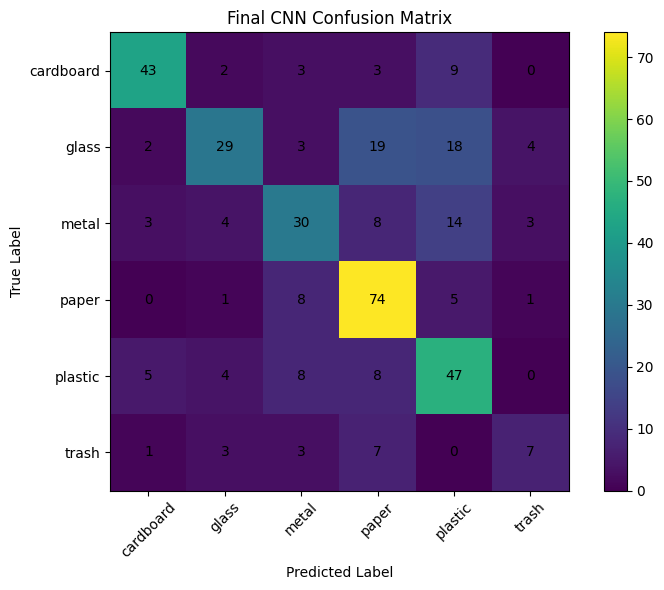

In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_cnn_final = confusion_matrix(
    y_true_cnn_final,
    y_pred_cnn_final
)

plt.figure(figsize=(8, 6))
plt.imshow(cm_cnn_final)
plt.title("Final CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(
    range(6),
    class_names,
    rotation=45
)

plt.yticks(
    range(6),
    class_names
)

for i in range(6):
    for j in range(6):
        plt.text(
            j, i,
            cm_cnn_final[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

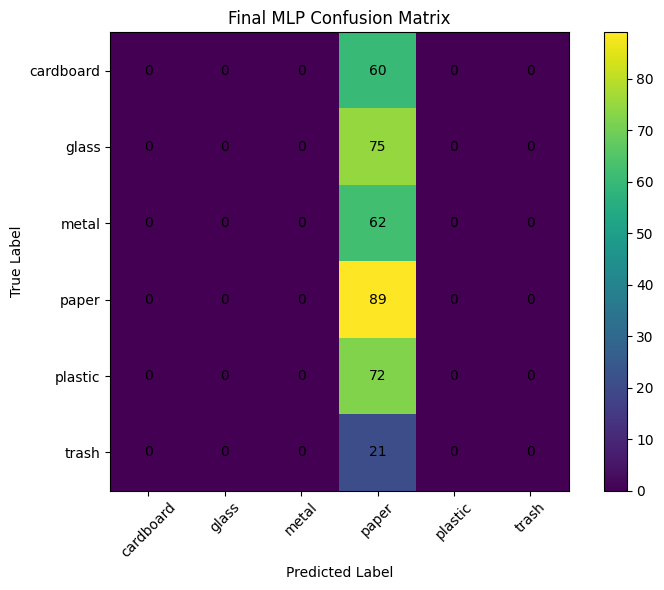

In [54]:
cm_mlp_final = confusion_matrix(
    y_true_mlp_final,
    y_pred_mlp_final
)

plt.figure(figsize=(8, 6))
plt.imshow(cm_mlp_final)
plt.title("Final MLP Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(
    range(6),
    class_names,
    rotation=45
)

plt.yticks(
    range(6),
    class_names
)

for i in range(6):
    for j in range(6):
        plt.text(
            j, i,
            cm_mlp_final[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()